In [1]:
# setup
model_folder = 'concat'
model_variant = 'microsoft_deberta-v3-large'
input_file = '../results/results_concat-microsoft_deberta-v3-large.xlsx'

In [2]:
import torch
import numpy as np
import pandas as pd
import os

import warnings
warnings.filterwarnings('ignore', message = 'Converting `np.inexact` or `np.floating` to a dtype is deprecated*')

from transformers import AutoModelForSequenceClassification, AutoTokenizer, TextClassificationPipeline

import shap
from shap.plots import colors

from captum.attr._utils.visualization import format_special_tokens
from matplotlib.colors import LinearSegmentedColormap
import PIL.Image as Image
import io
from IPython.core.display import HTML

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

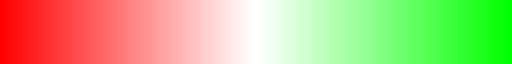

<div style="vertical-align: middle;"><strong>red_transparent_green</strong> </div><div class="cmap"></div><div style="vertical-align: middle; max-width: 514px; display: flex; justify-content: space-between;"><div style="float: left;"><div title="#ff0000ff" style="display: inline-block; width: 1em; height: 1em; margin: 0; vertical-align: middle; border: 1px solid #555; background-color: #ff0000ff;"></div> under</div><div style="margin: 0 auto; display: inline-block;">bad <div title="#00000000" style="display: inline-block; width: 1em; height: 1em; margin: 0; vertical-align: middle; border: 1px solid #555; background-color: #00000000;"></div></div><div style="float: right;">over <div title="#00ff00ff" style="display: inline-block; width: 1em; height: 1em; margin: 0; vertical-align: middle; border: 1px solid #555; background-color: #00ff00ff;"></div></div>

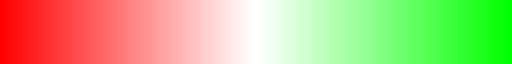

In [3]:
new_colors = []
for j in np.linspace(1, 0, 100):
    new_colors.append((255./255, 0./255, 0./255,j))
for j in np.linspace(0, 1, 100):
    new_colors.append((0./255, 255./255, 0./255,j))
red_transparent_green = LinearSegmentedColormap.from_list('red_transparent_green', new_colors)
display(red_transparent_green)
print(red_transparent_green._repr_html_())

with open('../results/color-scale.html', 'w') as f:
    f.write(red_transparent_green._repr_html_())

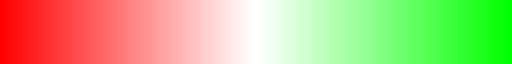

In [4]:
img = Image.open(io.BytesIO(red_transparent_green._repr_png_()))
display(img)
img.save('../results/color-scale.png')

In [5]:
def recolorize_shap (importance, color_map) -> str:
    scaled_val = 0.5 + 0.5 * importance
    color = color_map(scaled_val)
    color = (color[0] * 255, color[1] * 255, color[2] * 255, color[3])
    return f'rgba{color}'

def format_word_importances_alt (words, importances, color_map) -> str:
    if importances is None or len(importances) == 0:
        return '<td></td>'
    assert len(words) <= len(importances)
    tags = ['<td>']
    for word, importance in zip(words, importances[: len(words)]):
        word = format_special_tokens(word)
        color = recolorize_shap(importance, color_map)
        unwrapped_tag = '<mark style="border-radius: 3px; background-color: {color}; opacity:1.0; line-height:1.75"><font color="black">{word}</font></mark>'.format(
            color=color, word=word
        )
        tags.append(unwrapped_tag)
    tags.append('</td>')
    return ''.join(tags)

In [6]:
model_path = '../' + model_folder + '/models/' + model_variant
model_name = model_folder + '-' + model_path.split('/')[-1]

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path).to(device)

pipe = TextClassificationPipeline(model = model, tokenizer = tokenizer, top_k = None, device = device, batch_size = 128)

model_path

Device set to use cuda


'../concat/models/microsoft_deberta-v3-large'

In [7]:
new_data = pd.read_excel(input_file)
text = new_data['Statement'].tolist()

In [15]:
shap_values.data[3]

array(['', 'I', "'", 'm', ' not', ' certain', '.', ' Maybe', ' familiar',
       '.', ''], dtype=object)

In [8]:
explainer = shap.Explainer(pipe)
shap_values = explainer(text)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
PartitionExplainer explainer: 876it [11:14,  1.28it/s]                         


In [9]:
check_data = pd.DataFrame({
    'Text': text,
    'Apostrophe Count': [x.count("'") for x in text],
    'Space Split': [len(x.split(' ')) for x in text],
    'Token Split (Cleaned)': [np.sum(~np.isin(x.data, ['', '.', ',', '!', "'"])) for x in shap_values], # note: not all punctuation accounted for, e.g., / and ()
})

check_data['Equivalent'] = check_data['Space Split'] == check_data['Token Split (Cleaned)']
check_data['Equivalent (Apostrophe Correction)'] = check_data['Space Split'] == (check_data['Token Split (Cleaned)'] - check_data['Apostrophe Count'])
check_data.sort_values(['Equivalent (Apostrophe Correction)', 'Equivalent']).to_excel('../results/check-data.xlsx', index = True)

In [10]:
all_importances = np.array([])
for i, each in enumerate(shap_values):
    all_importances = np.concatenate((all_importances, each.values[:, -1]))
cmax = np.max(np.abs(all_importances))
cmax

0.28152017295360565

In [ ]:
display(HTML((format_word_importances_alt(shap_values[0].data, shap_values[0].values[:, -1] / cmax, red_transparent_green))))

In [12]:
new_data['HTML'] = [format_word_importances_alt(x.data, x.values[:, -1] / cmax, red_transparent_green) for x in shap_values]

In [13]:
if True:
    new_data.to_excel('../results/' + os.path.basename(input_file).split('.')[:-1][0] + '_with-interpretations.xlsx', index = False)